<a href="https://colab.research.google.com/github/YouriKaufmann/CVaR-Tool/blob/main/V3_EN_Climate_Stress_Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Read company data
chemin_excel = '/content/drive/MyDrive/content/drive/MyDrive/YOUR_PATH/CVaR_Tool_Template.xlsx'
df_companies = pd.read_excel(chemin_excel, sheet_name='Companies')

# 2b. Force numeric conversion on all financial columns
numeric_cols = [
    'Market_Cap', 'Total_Debt', 'Beta', 'Interest_Expense',
    'EBITDA', 'Total_Revenue', 'Scope_1_2', 'Scope_3',
    '%_of_Green_Revenue', 'Pass_Through',
    'Scope_3_SBTi_Current', 'Scope_3_SBTi_Baseline',
    'Carbon_Reduction_Plan_Scope_3','SBTi_Target_Year'
]
for col in numeric_cols:
    if col in df_companies.columns:
        df_companies[col] = (
            df_companies[col]
            .astype(str)
            .str.replace(' ', '', regex=False)
            .str.replace(',', '.', regex=False)
            .pipe(pd.to_numeric, errors='coerce')
        )

# 2c. Financial data entered in millions — convert to absolute units
millions_cols = [
    'Market_Cap', 'Total_Debt', 'Interest_Expense',
    'EBITDA', 'Total_Revenue'
]
for col in millions_cols:
    if col in df_companies.columns:
        df_companies[col] = df_companies[col] * 1_000_000

# 3. Read FX rates from Currencies sheet
df_currencies = pd.read_excel(chemin_excel, sheet_name='Currencies')
fx_map = df_currencies.set_index('Currency')['Value'].to_dict()

CURRENCY_TO_EUR = {'EUR': 1.0}  # EUR is always 1.0, not stored in sheet
CURRENCY_TO_EUR.update(fx_map)  # adds USD, CHF, GBP, DKK from Excel

# 4. Read carbon price trajectory from Carbon_Prices sheet
# Expected columns: Year / Current_Policies / Delayed_Transition / Net_Zero_2050
# Minimum required anchor points: 2025, 2030, 2035
df_carbon = pd.read_excel(chemin_excel, sheet_name='Carbon_Prices')
df_carbon = df_carbon.sort_values('Year').set_index('Year')

df_carbon = pd.read_excel(chemin_excel, sheet_name='Carbon_Prices')
df_carbon = df_carbon.sort_values('Year').set_index('Year')

# Force numeric conversion on all price columns
for col in df_carbon.columns:
    df_carbon[col] = (
        df_carbon[col]
        .astype(str)
        .str.replace(' ', '', regex=False)
        .str.replace(',', '.', regex=False)
        .pipe(pd.to_numeric, errors='coerce')
    )
# Also ensure the index (Year) is integer
df_carbon.index = df_carbon.index.astype(int)

# Build annual trajectory 2025→2035 (11 years) by linear interpolation
BASE_YEAR = 2025
HORIZON   = 11  # 2025, 2026, ..., 2035

years_full = list(range(BASE_YEAR, BASE_YEAR + HORIZON))  # [2025, ..., 2035]
df_carbon_interp = df_carbon.reindex(years_full).interpolate(method='index')

# Build scenario dictionary — arrays of length HORIZON
CARBON_TRAJECTORY = {
    'Current_Policies':   df_carbon_interp['Current_Policies'].values,
    'Delayed_Transition': df_carbon_interp['Delayed_Transition'].values,
    'Net_Zero_2050':      df_carbon_interp['Net_Zero_2050'].values,
}

# Active scenario — change here to switch
ACTIVE_SCENARIO = 'Delayed_Transition'

print("FX rates loaded:", CURRENCY_TO_EUR)
for scenario, prices in CARBON_TRAJECTORY.items():
    print(f"\nCarbon price trajectory ({scenario}):")
    for yr, price in zip(years_full, prices):
        print(f"  {yr}: €{price:.2f}/tCO2e")
print(df_companies)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
FX rates loaded: {'EUR': 1.0, 'USD': 0.855, 'CHF': 0.985, 'GBP': 1.13, 'DKK': 0.134}

Carbon price trajectory (Current_Policies):
  2025: €0.00/tCO2e
  2026: €0.00/tCO2e
  2027: €0.00/tCO2e
  2028: €0.00/tCO2e
  2029: €0.00/tCO2e
  2030: €0.00/tCO2e
  2031: €0.00/tCO2e
  2032: €0.00/tCO2e
  2033: €0.00/tCO2e
  2034: €0.00/tCO2e
  2035: €0.00/tCO2e

Carbon price trajectory (Delayed_Transition):
  2025: €0.00/tCO2e
  2026: €0.00/tCO2e
  2027: €0.00/tCO2e
  2028: €0.00/tCO2e
  2029: €0.00/tCO2e
  2030: €0.00/tCO2e
  2031: €19.09/tCO2e
  2032: €38.19/tCO2e
  2033: €57.28/tCO2e
  2034: €76.38/tCO2e
  2035: €95.47/tCO2e

Carbon price trajectory (Net_Zero_2050):
  2025: €15.60/tCO2e
  2026: €38.07/tCO2e
  2027: €60.54/tCO2e
  2028: €83.00/tCO2e
  2029: €105.47/tCO2e
  2030: €127.94/tCO2e
  2031: €152.05/tCO2e
  2032: €176.16/tCO2e
  2033: €200.28/tCO2e
  2034: €224.

In [8]:
# ── Scenario Parameters ───────────────────────────────────────────────────────
GREEN_MARKET_GROWTH = 0

# ── WACC Constants (update at each analysis date) ─────────────────────────────
RISK_FREE_RATE    = 0.0440   # US Treasury 10Y — Damodaran, May 2026
MARKET_RISK_PREMIUM = 0.0424   # Implied ERP — Damodaran, May 1, 2026
CORPORATE_TAX_RATE  = 0.25


def calculate_wacc(row, conversion_rate):
    """
    Computes company-specific WACC from static Excel inputs.
    All monetary values are in native currency; conversion_rate converts to EUR.

    Excel inputs required:
        Market_Cap       : market capitalisation (native currency)
        Total_Debt       : total financial debt (native currency)
        Beta             : equity beta (dimensionless)
        Interest_Expense : annual interest expense (native currency, positive value)
    """
    try:
        market_cap    = row['Market_Cap'] * conversion_rate
        total_debt    = row['Total_Debt'] * conversion_rate
        total_capital = market_cap + total_debt

        if total_capital == 0:
            return 0.071  # fallback

        weight_equity = market_cap / total_capital
        weight_debt   = total_debt / total_capital

        beta = row.get('Beta', 1.0)
        if pd.isna(beta) or beta <= 0:
            beta = 1.0

        cost_of_equity = RISK_FREE_RATE + beta * MARKET_RISK_PREMIUM

        interest_expense = abs(row.get('Interest_Expense', 0)) * conversion_rate
        if total_debt > 0 and interest_expense > 0:
            cost_of_debt = max(0.02, min(interest_expense / total_debt, 0.15))
        else:
            cost_of_debt = 0.04  # fallback

        wacc = (weight_equity * cost_of_equity) + \
               (weight_debt * cost_of_debt * (1 - CORPORATE_TAX_RATE))
        return round(max(0.04, min(wacc, 0.20)), 4)

    except Exception:
        return 0.071


def compute_scope3_reduction (scope3_total_current, scope3_sbti_current,
                                         scope3_sbti_baseline, reduction_plan,
                                         sbti_target_year, current_year):
    """
    Returns the effective Scope 3 reduction rate for a given year,
    assuming linear progression from 0 (current_year=BASE_YEAR)
    to full reduction (current_year=sbti_target_year).
    After sbti_target_year, reduction stays at maximum.

    New Excel input:
        SBTi_Target_Year : year by which the SBTi target is reached (e.g. 2030, 2035)
                           default = 2035 if not available
    """
    try:
        if pd.isna(scope3_sbti_baseline) or pd.isna(reduction_plan) or pd.isna(scope3_sbti_current):
            return 0.0
        if scope3_total_current <= 0 or scope3_sbti_current <= 0 or scope3_sbti_baseline <= 0:
            return 0.0

        # Full reduction rate (same logic as before)
        target_sbti        = scope3_sbti_baseline * (1 - reduction_plan)
        eff_reduction_sbti = max(0.0, 1 - (target_sbti / scope3_sbti_current))
        coverage           = scope3_sbti_current / scope3_total_current
        full_reduction     = eff_reduction_sbti * coverage

        # Linear ramp: 0 at BASE_YEAR, full_reduction at sbti_target_year
        if current_year >= sbti_target_year:
            progress = 1.0
        else:
            progress = (current_year - BASE_YEAR) / (sbti_target_year - BASE_YEAR)
            progress = max(0.0, progress)

        return full_reduction * progress

    except Exception:
        return 0.0

def calculate_cvar_and_sector(row, with_transition_plan=False):
    """
    Computes CVaR scores for a company from static Excel data.

    with_transition_plan=False : baseline run, current emissions unchanged.
    with_transition_plan=True  : applies declared Scope 3 reduction only.
                                  Scope 1+2 intentionally unchanged (market-based
                                  SBTi targets incompatible with location-based stress test).

    Carbon pricing: annual trajectory from Carbon_Prices sheet (NGFS, linearly interpolated).
    Horizon: 2025→2035 (11 years).

    Excel inputs required:
        Name, Ticker, Currency
        Market_Cap, Total_Debt, Beta, Interest_Expense, EBITDA, Total_Revenue
        Scope_1_2, Scope_3
        Scope_3_SBTi_Current, Scope_3_SBTi_Baseline, Carbon_Reduction_Plan_Scope_3
        Pass_Through, %_of_Green_Revenue
    """
    try:
        currency        = row.get('Currency', 'USD')
        conversion_rate = CURRENCY_TO_EUR.get(currency, 0.855)

        ebitda  = row['EBITDA'] * conversion_rate
        mkt_cap = row['Market_Cap'] * conversion_rate

        if ebitda == 0 or mkt_cap == 0:
            return pd.Series([None, None])

        scope_1_2 = row['Scope_1_2']
        scope_3   = row['Scope_3']

        wacc = calculate_wacc(row, conversion_rate)

       # ── Annual carbon price trajectory ───────────────────────────────────
        carbon_prices    = CARBON_TRAJECTORY[ACTIVE_SCENARIO]
        sbti_target_year = int(row.get('SBTi_Target_Year', 2035))

        pv_impact = 0.0
        for t in range(HORIZON):
            current_year = BASE_YEAR + t      # 2025, 2026, ..., 2035

            # Scope 3 reduction progressive for this year
            if with_transition_plan:
                eff_red_3_t = compute_scope3_reduction(
                    scope3_total_current = row['Scope_3'],
                    scope3_sbti_current  = row.get('Scope_3_SBTi_Current', np.nan),
                    scope3_sbti_baseline = row.get('Scope_3_SBTi_Baseline', np.nan),
                    reduction_plan       = row.get('Carbon_Reduction_Plan_Scope_3', np.nan),
                    sbti_target_year     = sbti_target_year,
                    current_year         = current_year
                )
                scope_3_t = row['Scope_3'] * (1 - eff_red_3_t)
            else:
                scope_3_t = row['Scope_3']

            total_emissions_t = row['Scope_1_2'] + scope_3_t
            price_t           = carbon_prices[t]
            gross_t           = total_emissions_t * price_t
            net_t             = gross_t * (1 - row['Pass_Through'])
            upside_t          = ebitda * row['%_of_Green_Revenue'] * GREEN_MARKET_GROWTH
            delta_cf_t        = upside_t - net_t
            pv_impact        += delta_cf_t / ((1 + wacc) ** (t + 1))
        # ─────────────────────────────────────────────────────────────────────

        cvar_score_mktcap = round((pv_impact / mkt_cap) * 100, 2)
        cvar_score_ebitda = round((pv_impact / ebitda) * 100, 2)

        return pd.Series([cvar_score_mktcap, cvar_score_ebitda])

    except Exception as e:
        print(f"Error for {row.get('Ticker', '?')}: {type(e).__name__} — {e}")
        return pd.Series([None, None])


# ── Execution ─────────────────────────────────────────────────────────────────
print("Run 1/2: Without transition plan (baseline)...")
df_companies[['CVaR_MktCap_NoPlan', 'CVaR_EBITDA_NoPlan']] = \
    df_companies.apply(lambda r: calculate_cvar_and_sector(r, with_transition_plan=False), axis=1)

print("Run 2/2: With transition plan (Scope 3 reduction applied)...")
df_companies[['CVaR_MktCap_WithPlan', 'CVaR_EBITDA_WithPlan']] = \
    df_companies.apply(lambda r: calculate_cvar_and_sector(r, with_transition_plan=True), axis=1)

df_companies['Delta_MktCap'] = df_companies['CVaR_MktCap_WithPlan'] - df_companies['CVaR_MktCap_NoPlan']
df_companies['Delta_EBITDA'] = df_companies['CVaR_EBITDA_WithPlan'] - df_companies['CVaR_EBITDA_NoPlan']

results_comparison = df_companies[[
    'Name', 'Ticker',
    'CVaR_MktCap_NoPlan', 'CVaR_EBITDA_NoPlan',
    'CVaR_MktCap_WithPlan', 'CVaR_EBITDA_WithPlan',
    'Delta_MktCap', 'Delta_EBITDA'
]].copy()

print(results_comparison)


Run 1/2: Without transition plan (baseline)...
Run 2/2: With transition plan (Scope 3 reduction applied)...
                Name Ticker  CVaR_MktCap_NoPlan  CVaR_EBITDA_NoPlan  \
0          Eli Lilly    LLY               -0.13               -6.44   
1  Johnson & Johnson    JNJ               -0.06               -1.21   
2       Novo Nordisk    NVO               -0.71               -7.25   
3              Roche    ROG               -0.12               -1.07   
4        AstraZeneca    AZN               -0.03               -0.62   
5             Sanofi    SAN               -0.28               -2.44   

   CVaR_MktCap_WithPlan  CVaR_EBITDA_WithPlan  Delta_MktCap  Delta_EBITDA  
0                 -0.10                 -5.06          0.03          1.38  
1                 -0.05                 -1.06          0.01          0.15  
2                 -0.56                 -5.76          0.15          1.49  
3                 -0.12                 -1.07          0.00          0.00  
4             

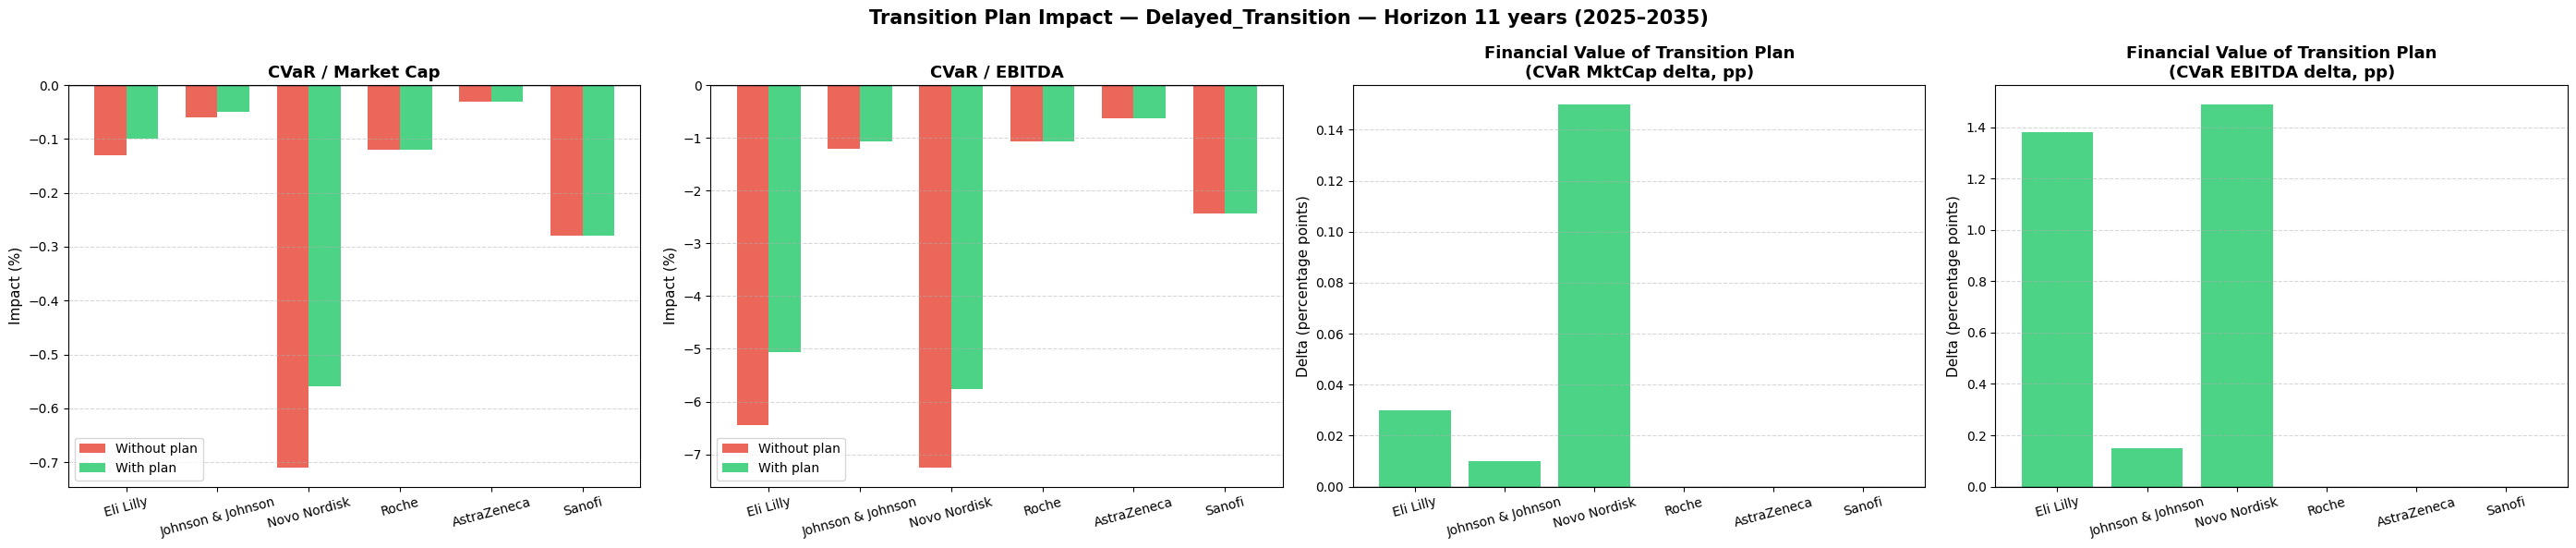

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(28, 6))
x     = np.arange(len(results_comparison['Name']))
width = 0.35

# Panel 1: CVaR Market Cap
axes[0].bar(x - width/2, results_comparison['CVaR_MktCap_NoPlan'],
            width, label='Without plan', color='#e74c3c', alpha=0.85)
axes[0].bar(x + width/2, results_comparison['CVaR_MktCap_WithPlan'],
            width, label='With plan', color='#2ecc71', alpha=0.85)
axes[0].set_title('CVaR / Market Cap', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Impact (%)', fontsize=11)
axes[0].set_xticks(x)
axes[0].set_xticklabels(results_comparison['Name'], rotation=15)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Panel 2: CVaR EBITDA
axes[1].bar(x - width/2, results_comparison['CVaR_EBITDA_NoPlan'],
            width, label='Without plan', color='#e74c3c', alpha=0.85)
axes[1].bar(x + width/2, results_comparison['CVaR_EBITDA_WithPlan'],
            width, label='With plan', color='#2ecc71', alpha=0.85)
axes[1].set_title('CVaR / EBITDA', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Impact (%)', fontsize=11)
axes[1].set_xticks(x)
axes[1].set_xticklabels(results_comparison['Name'], rotation=15)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# Panel 3: Delta MktCap
colors_mkt = ['#2ecc71' if v > 0 else '#e74c3c' for v in results_comparison['Delta_MktCap']]
axes[2].bar(results_comparison['Name'], results_comparison['Delta_MktCap'],
            color=colors_mkt, alpha=0.85)
axes[2].set_title('Financial Value of Transition Plan\n(CVaR MktCap delta, pp)',
                  fontsize=13, fontweight='bold')
axes[2].set_ylabel('Delta (percentage points)', fontsize=11)
axes[2].axhline(0, color='black', linewidth=1)
axes[2].tick_params(axis='x', rotation=15)
axes[2].grid(axis='y', linestyle='--', alpha=0.5)

# Panel 4: Delta EBITDA
colors_ebitda = ['#2ecc71' if v > 0 else '#e74c3c' for v in results_comparison['Delta_EBITDA']]
axes[3].bar(results_comparison['Name'], results_comparison['Delta_EBITDA'],
            color=colors_ebitda, alpha=0.85)
axes[3].set_title('Financial Value of Transition Plan\n(CVaR EBITDA delta, pp)',
                  fontsize=13, fontweight='bold')
axes[3].set_ylabel('Delta (percentage points)', fontsize=11)
axes[3].axhline(0, color='black', linewidth=1)
axes[3].tick_params(axis='x', rotation=15)
axes[3].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle(
    f'Transition Plan Impact — {ACTIVE_SCENARIO} — Horizon {HORIZON} years (2025–2035)',
    fontsize=15, fontweight='bold'
)
plt.tight_layout()
plt.show()


In [10]:
def calculate_cvar_audit_total(row):
    """
    Full audit run: returns all intermediate variables for transparency.
    Uses static Excel data only.
    Carbon pricing: annual trajectory (NGFS), linearly interpolated, 2025→2035.
    gross_carbon_cost and net_carbon_cost reported as NPV over the horizon.
    """
    try:
        currency        = row.get('Currency', 'USD')
        conversion_rate = CURRENCY_TO_EUR.get(currency, 0.855)

        ebitda  = row['EBITDA'] * conversion_rate
        mkt_cap = row['Market_Cap'] * conversion_rate

        if ebitda == 0 or mkt_cap == 0:
            return pd.Series([ebitda, mkt_cap, 0, 0, 0, 0, 0, None, None, None, None, None])

        emissions = row['Scope_1_2'] + row['Scope_3']
        wacc      = calculate_wacc(row, conversion_rate)

        carbon_prices = CARBON_TRAJECTORY[ACTIVE_SCENARIO]

        # Compute NPV of gross carbon cost, net carbon cost, upside, delta CF
        pv_gross = 0.0
        pv_net   = 0.0
        pv_up    = 0.0
        pv_delta = 0.0

        for t in range(HORIZON):
            price_t  = carbon_prices[t]
            gross_t  = emissions * price_t
            net_t    = gross_t * (1 - row['Pass_Through'])
            up_t     = ebitda * row['%_of_Green_Revenue'] * GREEN_MARKET_GROWTH
            delta_t  = up_t - net_t
            disc     = (1 + wacc) ** (t + 1)
            pv_gross += gross_t / disc
            pv_net   += net_t   / disc
            pv_up    += up_t    / disc
            pv_delta += delta_t / disc

        pv_impact = pv_delta

        cvar_score_mktcap = (pv_impact / mkt_cap) * 100
        cvar_score_ebitda = (pv_impact / ebitda)  * 100

        revenues         = row.get('Total_Revenue', 0) * conversion_rate
        carbon_intensity = round((emissions / (revenues / 1e6)), 2) if revenues > 0 else None

        total_debt   = row.get('Total_Debt', 0) * conversion_rate
        debt_ebitda  = round(total_debt / ebitda, 2) if ebitda > 0 else None

        return pd.Series([
            ebitda, mkt_cap, round(wacc, 4),
            pv_gross, pv_net,
            pv_up, pv_delta, pv_impact,
            round(cvar_score_mktcap, 2), round(cvar_score_ebitda, 2),
            carbon_intensity, debt_ebitda
        ])

    except Exception as e:
        print(f"Audit error for {row.get('Ticker', '?')}: {e}")
        return pd.Series([0, 0, 0, 0, 0, 0, 0, None, None, None, None, None])


cols_audit = [
    'EBITDA_EUR', 'Market_Cap_EUR', 'WACC',
    'gross_carbon_cost', 'net_carbon_cost',
    'Green_Upside', 'Delta_CF', 'Cumulative_Impact',
    'CVaR_Score_Mktcap', 'CVaR_Score_EBITDA',
    'carbon_intensity', 'debt_ebitda_ratio'
]
df_companies[cols_audit] = df_companies.apply(calculate_cvar_audit_total, axis=1)


In [11]:
def generate_expert_audit_report(df):
    ordre_lecture = [
        'Name', 'Ticker', 'Currency',
        'Scope_1_2', 'Scope_3',
        'carbon_intensity', 'debt_ebitda_ratio',
        'EBITDA_EUR', 'Market_Cap_EUR',
        'gross_carbon_cost', 'Pass_Through',
        'net_carbon_cost', '%_of_Green_Revenue', 'Green_Upside',
        'Delta_CF', 'WACC', 'Cumulative_Impact',
        'CVaR_MktCap_NoPlan', 'CVaR_EBITDA_NoPlan',
        'CVaR_MktCap_WithPlan', 'CVaR_EBITDA_WithPlan',
        'Delta_MktCap', 'Delta_EBITDA'
    ]
    cols_finales = [c for c in ordre_lecture if c in df.columns]
    df_trie = df[cols_finales].sort_values(by='CVaR_MktCap_NoPlan', ascending=False)

    return df_trie.style \
        .set_caption("Detailed Data: from CO2e to CVaR scores") \
        .format({
            'Scope_1_2':         '{:,.0f} t',
            'Scope_3':           '{:,.0f} t',
            'EBITDA_EUR':        lambda x: f"{x/1e6:,.0f} M€",
            'Market_Cap_EUR':    lambda x: f"{x/1e9:,.1f} Md€",
            'gross_carbon_cost': lambda x: f"-{x/1e6:,.1f} M€",
            'net_carbon_cost':   lambda x: f"-{x/1e6:,.1f} M€",
            'Green_Upside':      lambda x: f"+{x/1e6:,.1f} M€",
            'Delta_CF':          lambda x: f"{x/1e6:,.1f} M€",
            'Cumulative_Impact': lambda x: f"{x/1e6:,.1f} M€",
            'Pass_Through':             '{:.0%}',
            '%_of_Green_Revenue':       '{:.0%}',
            'WACC':                     '{:.1%}',
            'CVaR_MktCap_NoPlan':       '{:+.2f}%',
            'CVaR_EBITDA_NoPlan':       '{:+.2f}%',
            'CVaR_MktCap_WithPlan':     '{:+.2f}%',
            'CVaR_EBITDA_WithPlan':     '{:+.2f}%',
            'Delta_MktCap':             '{:+.2f} pp',
            'Delta_EBITDA':             '{:+.2f} pp',
            'carbon_intensity':         '{:,.1f} tCO2e/M€CA',
            'debt_ebitda_ratio':        '{:.1f}x',
        }) \
        .map(
            lambda v: f'color: {"#d65f5f" if v < 0 else "#5fba7d"}; font-weight: bold',
            subset=[
                'CVaR_MktCap_NoPlan', 'CVaR_EBITDA_NoPlan',
                'CVaR_MktCap_WithPlan', 'CVaR_EBITDA_WithPlan',
                'Delta_MktCap', 'Delta_EBITDA'
            ]
        ) \
        .set_properties(**{'text-align': 'right', 'font-size': '12px'}) \
        .set_table_styles([
            {'selector': 'th', 'props': [
                ('background-color', '#34495e'),
                ('color', 'white'),
                ('text-align', 'center')
            ]},
            {'selector': 'caption', 'props': [
                ('font-size', '16px'),
                ('font-weight', 'bold'),
                ('padding', '10px')
            ]}
        ])


print("Generating final audit table...")
df_audit = df_companies.copy()
generate_expert_audit_report(df_audit)


Generating final audit table...


,Name,Ticker,Currency,Scope_1_2,Scope_3,carbon_intensity,debt_ebitda_ratio,EBITDA_EUR,Market_Cap_EUR,gross_carbon_cost,Pass_Through,net_carbon_cost,%_of_Green_Revenue,Green_Upside,Delta_CF,WACC,Cumulative_Impact,CVaR_MktCap_NoPlan,CVaR_EBITDA_NoPlan,CVaR_MktCap_WithPlan,CVaR_EBITDA_WithPlan,Delta_MktCap,Delta_EBITDA
4,AstraZeneca,AZN,USD,"2,571 t","440,233 t",9.6 tCO2e/M€CA,2.3x,"12,996 M€",244.7 Md€,-80.3 M€,0%,-80.3 M€,0%,+0.0 M€,-80.3 M€,4.9%,-80.3 M€,-0.03%,-0.62%,-0.03%,-0.62%,+0.00 pp,+0.00 pp
1,Johnson & Johnson,JNJ,USD,"46,498 t","1,515,367 t",20.6 tCO2e/M€CA,2.1x,"22,327 M€",464.2 Md€,-269.6 M€,0%,-269.6 M€,0%,+0.0 M€,-269.6 M€,5.4%,-269.6 M€,-0.06%,-1.21%,-0.05%,-1.06%,+0.01 pp,+0.15 pp
3,Roche,ROG,CHF,"39,834 t","1,608,150 t",26.4 tCO2e/M€CA,2.1x,"28,664 M€",259.2 Md€,-308.0 M€,0%,-308.0 M€,0%,+0.0 M€,-308.0 M€,4.5%,-308.0 M€,-0.12%,-1.07%,-0.12%,-1.07%,+0.00 pp,+0.00 pp
0,Eli Lilly,LLY,USD,"187,591 t","6,236,869 t",104.0 tCO2e/M€CA,2.3x,"15,984 M€",817.9 Md€,"-1,029.8 M€",0%,"-1,029.8 M€",0%,+0.0 M€,"-1,029.8 M€",6.2%,"-1,029.8 M€",-0.13%,-6.44%,-0.10%,-5.06%,+0.03 pp,+1.38 pp
5,Sanofi,SAN,EUR,"37,327 t","1,664,398 t",39.5 tCO2e/M€CA,1.7x,"12,100 M€",106.0 Md€,-294.9 M€,0%,-294.9 M€,0%,+0.0 M€,-294.9 M€,5.4%,-294.9 M€,-0.28%,-2.44%,-0.28%,-2.44%,+0.00 pp,+0.00 pp
2,Novo Nordisk,NVO,DKK,"268,712 t","8,186,965 t",271.7 tCO2e/M€CA,0.7x,"19,758 M€",201.7 Md€,"-1,432.2 M€",0%,"-1,432.2 M€",0%,+0.0 M€,"-1,432.2 M€",5.6%,"-1,432.2 M€",-0.71%,-7.25%,-0.56%,-5.76%,+0.15 pp,+1.49 pp
